In [ ]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from hakken_ml_toolkit.ml_base_structures.data_generator import DummyDataGenerator

from kge.models.complex import ComplEx, ComplExConfig
from kge.negative_sampler import UniformNegativeSampler, UniformNegativeSamplerConfig
from kge.evaluator.ranking import KGERankingEvaluator, KGERankingEvaluatorConfig
from kge.common.constants import TargetType
from hakken_ml_toolkit.losses import MarginRankingLoss, MarginRankingLossConfig

torch.manual_seed(42)
np.random.seed(42)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


/home/ubuntu/Documents/GitHub/project_spaice_ds/packages/pip/kge/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Generate Synthetic Knowledge Graph

In [2]:
# Parameters for synthetic data
num_entities = 1000
num_relations = 50
num_triples = 5000

# Generate synthetic knowledge graph
kg = DummyDataGenerator.knowledge_graph(
    batch_size=num_triples,
    num_entities=num_entities,
    num_relations=num_relations,
    device=device,
    seed=42
)

print(f"Knowledge Graph Statistics:")
print(f"  - Entities: {kg.num_entities}")
print(f"  - Relations: {kg.num_relations}")
print(f"  - Training triples: {kg.facts_dict['train'].shape[0]}")
print(f"  - Validation triples: {kg.facts_dict['val'].shape[0]}")
print(f"  - Test triples: {kg.facts_dict['test'].shape[0]}")

# Display sample triples
sample_triples = kg.facts_dict['train'][:5].cpu().numpy()
sample_triples_decoded = []

for s, r, o in sample_triples:
    s_id = kg.entity_mapping.index_to_id[s.item()]
    r_id = kg.relation_mapping.index_to_id[r.item()]
    o_id = kg.entity_mapping.index_to_id[o.item()]
    sample_triples_decoded.append((s_id, r_id, o_id))

pd.DataFrame(sample_triples_decoded, columns=['Subject', 'Relation', 'Object'])

Knowledge Graph Statistics:
  - Entities: 1000
  - Relations: 50
  - Training triples: 5000
  - Validation triples: 5000
  - Test triples: 5000


,Subject,Relation,Object
0,entity_643,relation_3,entity_13
1,entity_981,relation_10,entity_593
2,entity_92,relation_23,entity_52
3,entity_216,relation_23,entity_731
4,entity_989,relation_23,entity_759


# Initialize the ComplEx Model

In [3]:
# Create output directory
output_dir = Path("./model_output")
output_dir.mkdir(exist_ok=True, parents=True)

# Model configuration
embedding_dim = 100
config = ComplExConfig(
    embedding_dim=embedding_dim,
    num_entities=kg.num_entities,
    num_relations=kg.num_relations,
)

# Initialize model
model = ComplEx(config).to(device)
print(f"Model initialized with embedding dimension: {embedding_dim}")

Model initialized with embedding dimension: 100


# Train the ComplEx Model


In [4]:
# Initialize negative sampler
neg_sampler_config = UniformNegativeSamplerConfig(
    num_negatives=10,
    filter_triples=["train"],
    corruption_scheme=[TargetType.OBJECT]
)
negative_sampler = UniformNegativeSampler(neg_sampler_config)
negative_sampler.set_up(kg, device)

# Initialize loss function
loss_fn = MarginRankingLoss(config=MarginRankingLossConfig(margin=1.0))

# Initialize optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training loop parameters
num_epochs = 10
batch_size = 128
num_batches = (len(kg.facts_dict['train']) + batch_size - 1) // batch_size

In [5]:
# Training loop
train_losses = []

model.train()
for epoch in range(num_epochs):
    # Shuffle training data
    indices = torch.randperm(len(kg.facts_dict['train']))
    total_loss = 0.0
    
    for batch_start in range(0, len(indices), batch_size):
        # Get batch indices
        batch_indices = indices[batch_start:batch_start + batch_size]
        
        # Get positive triples
        pos_triples = kg.facts_dict['train'][batch_indices].to(device)
        
        # Generate negative samples
        neg_triples_tensor = negative_sampler.corrupt_batch(pos_triples)
        neg_triples = neg_triples_tensor.view(-1, 3)
        
        # Forward pass for positive triples
        pos_scores = model.score(pos_triples)
        
        # Forward pass for negative triples
        neg_scores = model.score(neg_triples).view(pos_triples.shape[0], -1)
        
        # Calculate loss
        loss = loss_fn.compute(pos_scores, neg_scores)
        
        # Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    # Calculate average loss for the epoch
    avg_loss = total_loss / num_batches
    train_losses.append(avg_loss)
    
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

# Save the trained model
model_save_path = output_dir / "complex_model"
model.save(model_save_path)
print(f"Model saved to {model_save_path}")

Epoch 1/10, Loss: 1472.1319
Epoch 2/10, Loss: 1389.1683
Epoch 3/10, Loss: 1317.0626
Epoch 4/10, Loss: 1234.8595
Epoch 5/10, Loss: 1162.6607
Epoch 6/10, Loss: 1109.1889
Epoch 7/10, Loss: 1032.5099
Epoch 8/10, Loss: 967.9363
Epoch 9/10, Loss: 921.9759
Epoch 10/10, Loss: 867.1683
Model saved to model_output/complex_model


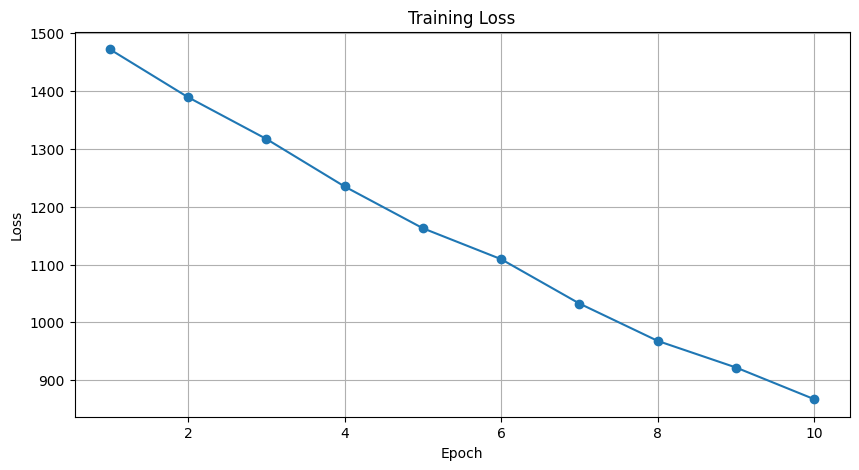

In [6]:

# Plot training loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), train_losses, marker='o')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.savefig(output_dir / "training_loss.png")
plt.show()

# Evaluate the model

In [7]:
# Initialize evaluator
evaluator_config = KGERankingEvaluatorConfig(
    metrics_config={
        "mrr": {},
        "hits_at_1": {"top_k": 1},
        "hits_at_3": {"top_k": 3},
        "hits_at_10": {"top_k": 10}
    },
    filter_list=["train"],
    target=[TargetType.OBJECT, TargetType.SUBJECT, TargetType.RELATION]
)
evaluator = KGERankingEvaluator(config=evaluator_config)
evaluator.set_up(kg)
# Set model to evaluation mode
model.eval()

ComplEx(
  (_entity_embeddings): Embedding(1000, 200)
  (_relation_embeddings): Embedding(50, 200)
)

In [8]:

# Evaluate on test data
test_triples = kg.facts_dict['test'].to(device)
evaluator.update_from_model(model=model, sro_batch=test_triples, batch_size=128)
metrics = evaluator.compute_metrics()

# Display evaluation results
metrics_df = pd.DataFrame([(k, v.item()) for k, v in metrics.items()], columns=['Metric', 'Value'])
metrics_df

,Metric,Value
0,object/mrr,0.007947
1,object/hits_at_1,0.000600
2,object/hits_at_3,0.002200
3,object/hits_at_10,0.009000
4,subject/mrr,0.008300
5,subject/hits_at_1,0.001000
6,subject/hits_at_3,0.002400
7,subject/hits_at_10,0.008600
8,relation/mrr,0.094395
9,relation/hits_at_1,0.025600


#  Link Prediction Inference

In [9]:
def get_entity_name(idx: int) -> str:
    return kg.entity_mapping.index_to_id[idx]

def get_relation_name(idx: int) -> str:
    return kg.relation_mapping.index_to_id[idx]

# Function for link prediction
def predict_links(subject_idx: int, relation_idx: int, top_k: int=5) -> list[dict]:
    """Predict the most likely objects for a given subject and relation"""
    model.eval()
    with torch.no_grad():
        # Create a batch with the query
        sr_batch = torch.tensor([[subject_idx, relation_idx]], dtype=torch.long).to(device)
        
        # Get scores for all possible objects
        scores = model.score_objects(sr_batch).cpu().numpy()[0]
        
        # Get top k indices
        top_indices = np.argsort(scores)[::-1][:top_k]
        
        # Get scores for top k
        top_scores = scores[top_indices]
        
        # Create results
        results = []
        for idx, score in zip(top_indices, top_scores):
            results.append({
                'object_idx': idx,
                'object': get_entity_name(idx),
                'score': score
            })
        
        return results

subject_idx = 10 
relation_idx = 5 

print(f"Query: {get_entity_name(subject_idx)} --[{get_relation_name(relation_idx)}]--> ?")
predictions = predict_links(subject_idx, relation_idx, top_k=5)
pd.DataFrame(predictions)

Query: entity_10 --[relation_5]--> ?


,object_idx,object,score
0,618,entity_618,65.479378
1,791,entity_791,65.335152
2,223,entity_223,58.753914
3,83,entity_83,54.230881
4,983,entity_983,47.688843


# Load a Saved Model

In [10]:
loaded_model = ComplEx.load(model_save_path, device=device)
print(f"Model loaded from {model_save_path}")

test_subject_idx = 10
test_relation_idx = 5
print(f"Test query: {get_entity_name(test_subject_idx)} --[{get_relation_name(test_relation_idx)}]--> ?")
test_predictions = predict_links(test_subject_idx, test_relation_idx, top_k=3)
pd.DataFrame(test_predictions)

Model loaded from model_output/complex_model
Test query: entity_10 --[relation_5]--> ?


,object_idx,object,score
0,618,entity_618,65.479378
1,791,entity_791,65.335152
2,223,entity_223,58.753914
